# 04 · KPI Layer — One Source of Truth for Every Number

**Business objective.** Modules 2–4 produced clean data and dozens of analyses — but an
analytics function lives or dies on *governed metrics*: every number quoted in a meeting
must have exactly one definition, one formula, and one place to look it up. This notebook
builds that layer.

**What this notebook does**

1. Implements the **25 KPIs** defined in [`docs/kpi_definitions.md`](../docs/kpi_definitions.md)
   across five pillars — *Audience & Growth, Revenue, Retention & Churn, Engagement,
   Quality & Satisfaction* — from the star schema.
2. Builds a **monthly KPI engine** (42 months, Jan 2023 → Jun 2026) so every headline
   number also has a trend behind it.
3. Exports three **Power BI-ready tables** (`powerbi/kpi_snapshot.csv`,
   `kpi_monthly.csv`, `kpi_by_plan.csv`) that Module 7's dashboard will consume.
4. **Validates** the pandas numbers against the SQLite layer (Module 4), so the SQL and
   Python implementations provably agree.

> Snapshot KPIs are measured **as of 2026-06-30**, the dataset export date.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# ---- palette (validated categorical order + chrome inks, same as Module 3) ----
CAT = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
BLUE, AMBER = CAT[0], CAT[3]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "font.family": "Segoe UI", "text.color": INK, "axes.edgecolor": BASE,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})


def style(ax, pct=False, dollars=False):
    """Recessive chrome: hairline grid on the value axis only."""
    ax.grid(axis="y")
    if pct:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    if dollars:
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))


def end_label(ax, x, y, text):
    """Direct label on the last point of a trend line."""
    ax.annotate(text, (x, y), xytext=(7, 0), textcoords="offset points",
                va="center", color=INK, fontweight="bold", fontsize=10)


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
P = PROJECT_ROOT / "data" / "processed"
AS_OF = pd.Timestamp("2026-06-30")

subs = pd.read_csv(P / "fact_subscriptions.csv",
                   parse_dates=["Subscription_Start_Date", "Subscription_End_Date"])
users = pd.read_csv(P / "dim_user.csv")
dates = pd.read_csv(P / "dim_date.csv", parse_dates=["Date"])
ev = pd.read_csv(P / "fact_watch_events.csv", parse_dates=["Watch_Date"])
ev["Day"] = ev["Watch_Date"].dt.normalize()
ev["Month"] = ev["Watch_Date"].dt.to_period("M")

print(f"{len(users):,} users | {len(subs):,} subscriptions | {len(ev):,} watch events | as-of {AS_OF:%Y-%m-%d}")

7,993 users | 7,993 subscriptions | 41,046 watch events | as-of 2026-06-30


## Conventions — and one data-quality decision made explicit

All formulas follow [`docs/kpi_definitions.md`](../docs/kpi_definitions.md). Two conventions
matter enough to restate:

- **Active subscriber** = `Subscription_Status = 'Active'` (contract-based).
  **MAU** = a user with ≥ 1 watch event in the month (behaviour-based). They answer
  different questions and are never interchanged.
- **Active during month M** = started on or before M's last day, and not cancelled before
  M's first day. **Active at end of M** (used for MRR/ARPU trend points) = started by M's
  last day and still active after it.

**The 36 undated cancellations.** Reconciling status against dates surfaced 36 users
(0.45% of the base) whose status is *Cancelled* but whose end date was unrecoverable in
cleaning. Decision: **status is authoritative** — they count as churned in every lifetime
KPI, but they cannot be placed on the monthly timeline, so the monthly engine excludes
them (documented here rather than silently absorbed; with them the June-2026 trend
endpoint would overstate actives by 36 and MRR by ~$140).

**Partial months.** Jan 2023 starts mid-month (first sign-up Jan 19), so trend charts
begin Feb 2023; the export keeps all 42 months with an `Is_Partial_Month` flag.

In [2]:
# ---- the monthly KPI engine: one row per calendar month, Jan 2023 -> Jun 2026 ----

# status is authoritative: the 36 undated cancellations stay in lifetime KPIs,
# but can't be placed on a monthly timeline
dated = subs[(subs["Subscription_Status"] == "Active") | subs["Subscription_End_Date"].notna()]
start, end, fee = (dated["Subscription_Start_Date"], dated["Subscription_End_Date"],
                   dated["Monthly_Fee"])

rows = []
for m in pd.period_range("2023-01", "2026-06", freq="M"):
    som, eom = m.start_time, m.end_time.normalize()
    active_at_start = ((start < som) & (end.isna() | (end >= som))).sum()
    cancels = end.between(som, eom).sum()
    at_eom = (start <= eom) & (end.isna() | (end > eom))   # still active after month end
    rows.append({
        "Month": m,
        "New_Subscribers": start.between(som, eom).sum(),
        "Cancellations": cancels,
        "Active_Start": active_at_start,
        "Monthly_Churn_Rate": cancels / active_at_start if active_at_start else np.nan,
        "Active_EOM": at_eom.sum(),
        "Paying_EOM": (at_eom & (fee > 0)).sum(),
        "MRR": fee[at_eom].sum(),
    })
monthly = pd.DataFrame(rows).set_index("Month")
monthly["ARPU"] = monthly["MRR"] / monthly["Active_EOM"]

# behaviour KPIs from watch events
g = ev.groupby("Month")
monthly["MAU"] = g["User_ID"].nunique()
monthly["Avg_DAU"] = ev.groupby(["Month", "Day"])["User_ID"].nunique().groupby("Month").mean()
monthly["Stickiness"] = monthly["Avg_DAU"] / monthly["MAU"]
monthly["Watch_Hours"] = g["Watch_Time_Minutes"].sum() / 60
monthly["Hours_per_MAU"] = monthly["Watch_Hours"] / monthly["MAU"]
monthly["Completion_Rate"] = g["Completion_Percentage"].mean()
monthly["Avg_Rating"] = g["User_Rating"].mean()
monthly["Ad_CTR"] = g["Ad_Clicked"].sum() / g["Ad_Shown"].sum()
user_days = ev.groupby(["Month", "User_ID", "Day"]).size()
monthly["Binge_Rate"] = (user_days >= 3).groupby("Month").mean()

# season-launch months (from the date dimension) — used to annotate trend charts
monthly["Season_Launch"] = (dates.assign(Month=dates["Date"].dt.to_period("M"))
                                 .groupby("Month")["Is_Season_Launch"].max())
monthly["Is_Partial_Month"] = monthly.index == pd.Period("2023-01")

# the KPI collector: every pillar appends here; the snapshot table + export read from it
KPIS = []
def kpi(kpi_id, pillar, name, value, unit, definition):
    KPIS.append({"KPI_ID": kpi_id, "Pillar": pillar, "KPI": name, "Value": round(float(value), 4),
                 "Unit": unit, "As_Of": AS_OF.date().isoformat(), "Definition": definition})
    return value

monthly.tail(6).round(3)

,New_Subscribers,Cancellations,Active_Start,Monthly_Churn_Rate,Active_EOM,Paying_EOM,MRR,ARPU,MAU,Avg_DAU,Stickiness,Watch_Hours,Hours_per_MAU,Completion_Rate,Avg_Rating,Ad_CTR,Binge_Rate,Season_Launch,Is_Partial_Month
Month,,,,,,,,,,,,,,,,,,,
2026-01,330,218,2943,0.074,3055,2077,19144.23,6.267,1514,65.032,0.043,705.540,0.466,61.566,7.789,0.076,0.070,True,False
2026-02,280,195,3055,0.064,3140,2123,19593.77,6.240,934,39.107,0.042,381.863,0.409,62.179,7.878,0.062,0.064,False,False
2026-03,307,198,3140,0.063,3249,2207,20452.93,6.295,1015,39.065,0.038,414.582,0.408,61.859,7.835,0.069,0.064,False,False
2026-04,311,213,3249,0.066,3347,2281,21267.19,6.354,1637,69.700,0.043,720.138,0.440,62.310,7.753,0.089,0.063,True,False
2026-05,340,211,3347,0.063,3476,2390,22266.10,6.406,1192,45.097,0.038,481.238,0.404,62.238,7.842,0.104,0.064,False,False
2026-06,320,272,3476,0.078,3524,2422,22550.78,6.399,1527,58.483,0.038,524.070,0.343,60.803,7.709,0.076,0.054,False,False


## Pillar A — Audience & Growth

*Is the audience growing, and does it actually show up?* Six KPIs: the contract-based
base size (registered, active, new per month) and the behaviour-based audience
(MAU, DAU, stickiness). The gap between the two views — subscribers who pay but don't
watch — is tomorrow's churn.

In [3]:
last = monthly.loc[pd.Period("2026-06")]
prev_year = monthly.loc[pd.Period("2025-06")]
active = subs[subs["Subscription_Status"] == "Active"]

total_users = kpi("A1", "Audience & Growth", "Total Registered Users", len(users), "users",
                  "COUNT(DISTINCT User_ID) in dim_user")
active_subs = kpi("A2", "Audience & Growth", "Active Subscribers", len(active), "users",
                  "Users with Subscription_Status = 'Active'")
new_subs = kpi("A3", "Audience & Growth", "New Subscribers (Jun 2026)", last["New_Subscribers"], "users",
               "Subscription starts in the last full month")
mau = kpi("A4", "Audience & Growth", "MAU (Jun 2026)", last["MAU"], "users",
          "Distinct users with >=1 watch event in the month")
dau = kpi("A5", "Audience & Growth", "Avg DAU (Jun 2026)", last["Avg_DAU"], "users",
          "Daily distinct viewers, averaged across the month")
stick = kpi("A6", "Audience & Growth", "Stickiness DAU/MAU (Jun 2026)", last["Stickiness"], "ratio",
            "Avg DAU divided by MAU, same month")

print(f"Registered users            {total_users:>10,}")
print(f"Active subscribers          {active_subs:>10,}   ({active_subs / total_users:.1%} of ever-registered)")
print(f"New subscribers, Jun 2026   {new_subs:>10,.0f}   (12-month avg: {monthly['New_Subscribers'].tail(12).mean():,.0f}/month)")
print(f"MAU, Jun 2026               {mau:>10,.0f}   (Jun 2025: {prev_year['MAU']:,.0f}  ->  {last['MAU'] / prev_year['MAU'] - 1:+.0%} YoY)")
print(f"Avg DAU, Jun 2026           {dau:>10,.1f}")
print(f"Stickiness (DAU/MAU)        {stick:>10.3f}   (~{stick * 30:.1f} viewing days per active user per month)")

Registered users                 7,993
Active subscribers               3,524   (44.1% of ever-registered)
New subscribers, Jun 2026          320   (12-month avg: 304/month)
MAU, Jun 2026                    1,527   (Jun 2025: 695  ->  +120% YoY)
Avg DAU, Jun 2026                 58.5
Stickiness (DAU/MAU)             0.038   (~1.1 viewing days per active user per month)


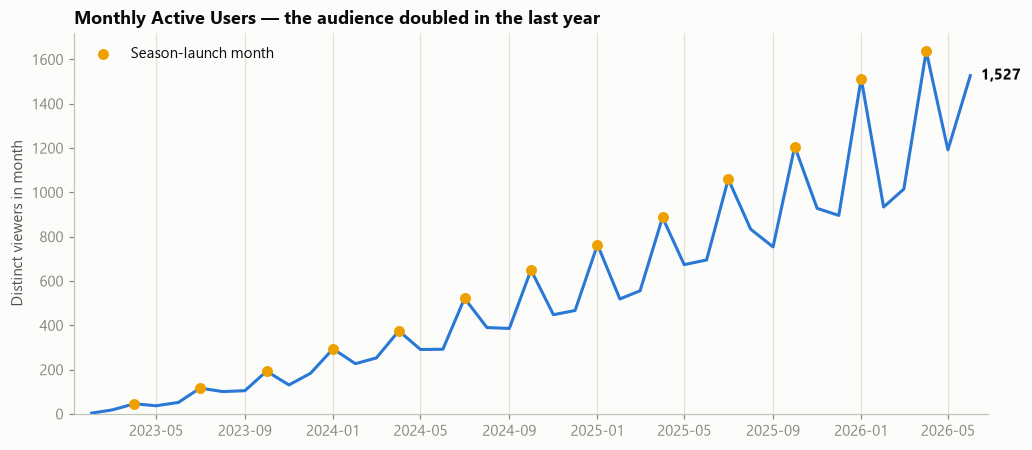

In [4]:
m = monthly.iloc[1:]                      # drop partial Jan 2023 from charts
x = m.index.to_timestamp()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(x, m["MAU"], color=BLUE, lw=2, zorder=3)
launch = m[m["Season_Launch"]]
ax.scatter(launch.index.to_timestamp(), launch["MAU"], color=AMBER, s=38, zorder=4,
           label="Season-launch month")
end_label(ax, x[-1], m["MAU"].iloc[-1], f"{m['MAU'].iloc[-1]:,.0f}")
ax.set_title("Monthly Active Users — the audience doubled in the last year")
ax.set_ylabel("Distinct viewers in month")
ax.set_ylim(bottom=0)
ax.legend(loc="upper left")
ax.margins(x=0.02)
style(ax)
plt.tight_layout()
plt.show()

**Insight.** MAU reached **1,527 in June 2026, +120% YoY** (695 in June 2025), with the
2026 peak at 1,637 (April). The orange markers show the pattern that matters
operationally: **audience spikes land on season-launch months** — content drops, people
show up. The sobering counterweight is **stickiness at 0.038**: the average active user
watches on ~1.2 days per month, far below the 0.15–0.30 streaming benchmark. Growth is
currently *acquisition- and content-drop-driven*, not habit-driven — the clearest
product opportunity in this pillar.

## Pillar B — Revenue

*What is the business worth per month, and who funds it?* MRR is the run-rate headline;
ARPU vs ARPPU separates "monetize the base better" from "price the payers better"; paid
conversion prices the free tier.

In [5]:
paying = active[active["Monthly_Fee"] > 0]

mrr = kpi("B1", "Revenue", "MRR", active["Monthly_Fee"].sum(), "USD",
          "SUM(Monthly_Fee) over active subscribers")
ltr = kpi("B2", "Revenue", "Total Collected Revenue (lifetime)", subs["Revenue"].sum(), "USD",
          "SUM(Revenue) over all subscriptions")
arpu = kpi("B3", "Revenue", "ARPU (monthly)", mrr / len(active), "USD",
           "MRR / active subscribers (Free included)")
arppu = kpi("B4", "Revenue", "ARPPU (monthly)", mrr / len(paying), "USD",
            "MRR / active paying subscribers")
conv = kpi("B5", "Revenue", "Paid Conversion Rate", (subs["Monthly_Fee"] > 0).mean(), "pct",
           "Users ever on a paid plan / total registered users")

mix = active.groupby("Subscription_Plan")["Monthly_Fee"].sum().sort_values(ascending=False)
mix = mix[mix > 0]

print(f"MRR                         ${mrr:>12,.2f}   (Jun 2025: ${prev_year['MRR']:,.2f}  ->  {mrr / prev_year['MRR'] - 1:+.0%} YoY)")
print(f"Lifetime collected revenue  ${ltr:>12,.2f}")
print(f"ARPU  (all active)          ${arpu:>12,.2f}")
print(f"ARPPU (paying active)       ${arppu:>12,.2f}")
print(f"Paid conversion rate        {conv:>13.1%}")
print("MRR mix: " + "  |  ".join(f"{p}: ${v:,.0f} ({v / mrr:.0%})" for p, v in mix.items()))

MRR                         $   22,550.78   (Jun 2025: $13,305.51  ->  +69% YoY)
Lifetime collected revenue  $  374,693.93
ARPU  (all active)          $        6.40
ARPPU (paying active)       $        9.31
Paid conversion rate                60.0%
MRR mix: Premium: $11,059 (49%)  |  Family: $7,390 (33%)  |  Basic: $4,102 (18%)


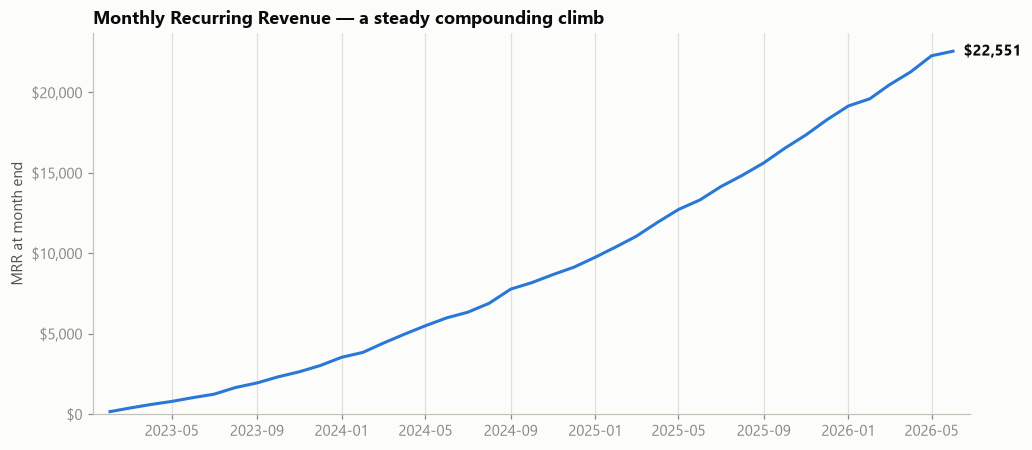

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(x, m["MRR"], color=BLUE, lw=2, zorder=3)
end_label(ax, x[-1], m["MRR"].iloc[-1], f"${m['MRR'].iloc[-1]:,.0f}")
ax.set_title("Monthly Recurring Revenue — a steady compounding climb")
ax.set_ylabel("MRR at month end")
ax.set_ylim(bottom=0)
ax.margins(x=0.02)
style(ax, dollars=True)
plt.tight_layout()
plt.show()

**Insight.** MRR closed June 2026 at **$22,551, +70% YoY**, and the curve is smooth —
revenue compounds because the paying base grows steadily even while engagement is spiky.
The mix tells the pricing story: **Premium contributes 49% of MRR, Family 33%, Basic 18%**,
so ARPPU ($9.31) sits near the Premium price point. ARPU across the whole active base is
$6.40 — the 31% gap between ARPU and ARPPU is the revenue cost of carrying a large free
tier, and it shrinks only through conversion (60.0% of users have ever paid).

## Pillar C — Retention & Churn

*How fast does the bucket leak?* Lifetime churn grades acquisition quality; **monthly
churn** is the operating number a dashboard should carry; early-churn share and average
lifetime price the onboarding problem and feed the LTV estimate.

In [7]:
churned = subs[subs["Subscription_Status"] == "Cancelled"]

churn_all = kpi("C1", "Retention & Churn", "Overall Churn Rate (lifetime)",
                len(churned) / len(subs), "pct", "Cancelled users / total registered users")
churn_m = kpi("C2", "Retention & Churn", "Monthly Churn Rate (Jun 2026)",
              last["Monthly_Churn_Rate"], "pct",
              "Cancellations in month / active at month start")
early = kpi("C3", "Retention & Churn", "Early Churn Share (<=3m)",
            (churned["Membership_Tenure"] <= 3).mean(), "pct",
            "Churned with tenure <= 3 months / all churned")
lifetime = kpi("C4", "Retention & Churn", "Avg Customer Lifetime",
               churned["Membership_Tenure"].mean(), "months",
               "AVG(Membership_Tenure) over churned users")
loyal = kpi("C5", "Retention & Churn", "Loyal Share (12m+ active)",
            (users["Retention_Status"] == "Loyal (12m+ active)").mean(), "pct",
            "Retention_Status = 'Loyal (12m+ active)' / total users")

print(f"Overall churn (lifetime)    {churn_all:>10.1%}")
print(f"Monthly churn, Jun 2026     {churn_m:>10.1%}   (2024 avg: {monthly.loc['2024', 'Monthly_Churn_Rate'].mean():.1%}  ->  2026 H1 avg: {monthly.loc['2026', 'Monthly_Churn_Rate'].mean():.1%})")
print(f"Early churn share (<=3m)    {early:>10.1%}")
print(f"Avg customer lifetime       {lifetime:>10.1f} months  ->  LTV ~= ARPPU x lifetime = ${arppu * lifetime:,.2f}")
print(f"Loyal share (12m+ active)   {loyal:>10.1%}")

Overall churn (lifetime)         55.9%
Monthly churn, Jun 2026           7.8%   (2024 avg: 8.5%  ->  2026 H1 avg: 6.8%)
Early churn share (<=3m)         58.6%
Avg customer lifetime              5.0 months  ->  LTV ~= ARPPU x lifetime = $46.62
Loyal share (12m+ active)        16.5%


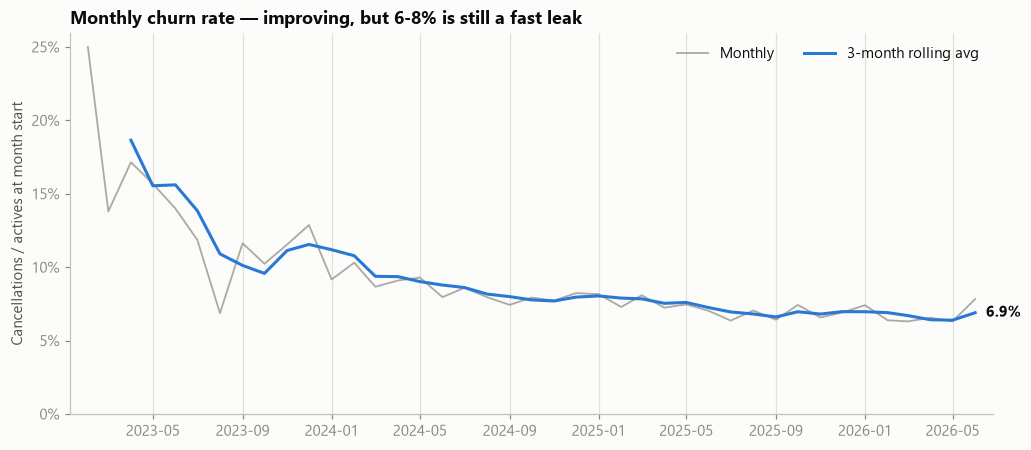

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(x, m["Monthly_Churn_Rate"], color=MUTED, lw=1.2, alpha=0.7, label="Monthly")
roll = m["Monthly_Churn_Rate"].rolling(3).mean()
ax.plot(x, roll, color=BLUE, lw=2, zorder=3, label="3-month rolling avg")
end_label(ax, x[-1], roll.iloc[-1], f"{roll.iloc[-1]:.1%}")
ax.set_title("Monthly churn rate — improving, but 6-8% is still a fast leak")
ax.set_ylabel("Cancellations / actives at month start")
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", ncols=2)
ax.margins(x=0.02)
style(ax, pct=True)
plt.tight_layout()
plt.show()

**Insight.** Monthly churn has **improved from ~8.5% (2024 avg) to ~6.8% (2026 H1)** but
remains high in absolute terms — at ~7%/month, half of a cohort is gone within 10 months,
which is exactly what the **5.0-month average lifetime** and **55.9% lifetime churn**
say. The structure of the leak is the actionable part: **58.6% of all churn happens in
the first 3 months**, so the highest-leverage retention spend is onboarding (first-week
content activation), not win-back. The prize for fixing it: with ARPPU at $9.31, each
month of added average lifetime is worth ~$9.31 per paying churner — LTV currently
~**$46.62**, and the 16.5% proven-loyal core shows the product can hold people once the
early cliff is survived.

## Pillar D — Engagement

*Once people are here, how deeply do they watch?* Gross hours feed licensing decisions;
hours-per-MAU separates "more viewers" from "more viewing"; completion, binge rate and
the composite engagement score describe the quality of a viewing session.

In [9]:
hours = kpi("D1", "Engagement", "Total Watch Hours", ev["Watch_Time_Minutes"].sum() / 60, "hours",
            "SUM(Watch_Time_Minutes)/60 over all events")
hpm = kpi("D2", "Engagement", "Watch Hours per MAU (Jun 2026)", last["Hours_per_MAU"], "hours",
          "Monthly watch hours / MAU")
compl = kpi("D3", "Engagement", "Avg Completion Rate", ev["Completion_Percentage"].mean(), "pct100",
            "AVG(Completion_Percentage) over recorded events")
compl90 = kpi("D4", "Engagement", "Completed Share (>=90%)",
              (ev["Completion_Percentage"] >= 90).mean(), "pct",
              "Events with completion >= 90% / all events")
binge = kpi("D5", "Engagement", "Binge Rate",
            (ev.groupby(["User_ID", "Day"]).size() >= 3).mean(), "pct",
            "User-days with >=3 episodes / all user-days")
eng = kpi("D6", "Engagement", "Avg Engagement Score", users["Engagement_Score"].mean(), "score",
          "AVG(Engagement_Score) from dim_user (0-100 composite)")

print(f"Total watch hours           {hours:>12,.0f}")
print(f"Hours per MAU, Jun 2026     {hpm:>12.2f}   (2023 avg: {monthly.loc['2023', 'Hours_per_MAU'].mean():.2f}  ->  2026 avg: {monthly.loc['2026', 'Hours_per_MAU'].mean():.2f})")
print(f"Avg completion              {compl:>11.1f}%   (share finishing >=90%: {compl90:.1%})")
print(f"Binge rate (3+ eps/day)     {binge:>12.1%}")
print(f"Avg engagement score        {eng:>12.1f} / 100")

Total watch hours                  9,681
Hours per MAU, Jun 2026             0.34   (2023 avg: 0.37  ->  2026 avg: 0.41)
Avg completion                     61.5%   (share finishing >=90%: 4.5%)
Binge rate (3+ eps/day)             6.5%
Avg engagement score                50.0 / 100


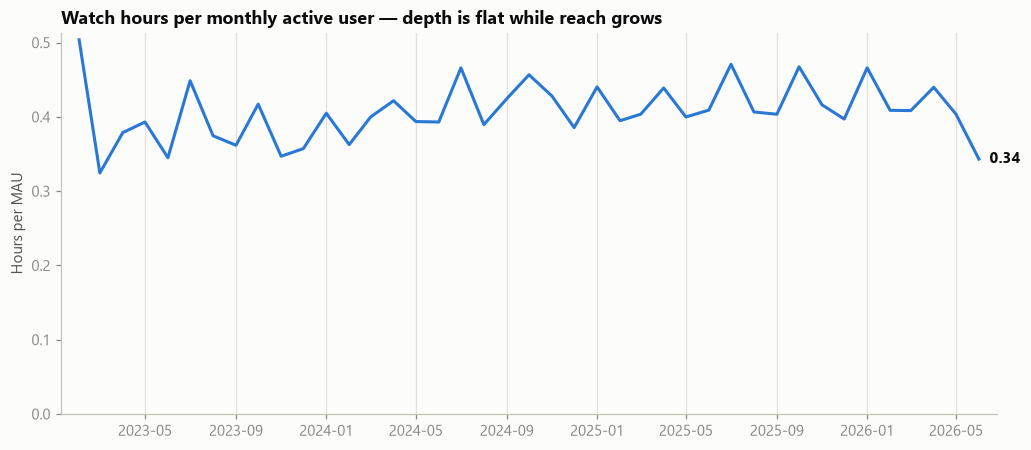

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(x, m["Hours_per_MAU"], color=BLUE, lw=2, zorder=3)
end_label(ax, x[-1], m["Hours_per_MAU"].iloc[-1], f"{m['Hours_per_MAU'].iloc[-1]:.2f}")
ax.set_title("Watch hours per monthly active user — depth is flat while reach grows")
ax.set_ylabel("Hours per MAU")
ax.set_ylim(bottom=0)
ax.margins(x=0.02)
style(ax)
plt.tight_layout()
plt.show()

**Insight.** Depth per viewer is **flat** — hours-per-MAU has hovered around 0.4 for
three years (2023 avg 0.37 → 2026 avg 0.41) while MAU doubled: the platform is adding
viewers, not viewing. Sessions are shallow — **average completion is 61.5%**, only
**4.5% of episode plays reach the 90%+ "completed" bucket**, and just **6.5% of viewing
days become binges** (3+ episodes). Together with the low stickiness from Pillar A this
is a consistent picture: *discovery brings people in on launch days, but the product
doesn't yet convert a visit into a habit* — the Module 6 business questions will chase
which genres/devices break that pattern.

## Pillar E — Quality & Satisfaction

*How does the experience feel, and does the free tier earn its keep?* CSAT and content
ratings are the perception layer that *leads* churn; buffering is the delivery-side lever
on both; ad CTR is the free tier's revenue engine.

In [11]:
csat = kpi("E1", "Quality & Satisfaction", "CSAT (avg, 1-10)",
           users["Customer_Satisfaction"].mean(), "score", "AVG(Customer_Satisfaction), 1-10 scale")
csat8 = kpi("E2", "Quality & Satisfaction", "Satisfied Share (CSAT >= 8)",
            (users["Customer_Satisfaction"] >= 8).mean(), "pct", "Users scoring >= 8 / all users")
rating = kpi("E3", "Quality & Satisfaction", "Avg Content Rating",
             ev["User_Rating"].mean(), "score", "AVG(User_Rating) over rated events (1-10)")
buff = kpi("E4", "Quality & Satisfaction", "Avg Buffering per Event",
           ev["Buffering_Time"].mean(), "minutes", "AVG(Buffering_Time) per watch event")
ctr = kpi("E5", "Quality & Satisfaction", "Ad CTR (Free tier)",
          ev["Ad_Clicked"].sum() / ev["Ad_Shown"].sum(), "pct", "SUM(Ad_Clicked)/SUM(Ad_Shown)")

rated_share = ev["User_Rating"].notna().mean()
print(f"CSAT (1-10)                 {csat:>10.2f}   (satisfied >=8: {csat8:.1%})")
print(f"Avg content rating          {rating:>10.2f}   (volunteered on {rated_share:.0%} of events - selection bias applies)")
print(f"Avg buffering per event     {buff:>10.2f} min")
print(f"Ad CTR (free tier)          {ctr:>10.1%}")

CSAT (1-10)                       7.07   (satisfied >=8: 35.6%)
Avg content rating                7.77   (volunteered on 46% of events - selection bias applies)
Avg buffering per event           8.91 min
Ad CTR (free tier)                7.8%


**Insight.** Content is not the problem — volunteered ratings average **7.77/10**. The
experience around it is weaker: **CSAT averages 7.07 with only 35.6% of users at 8+**,
and the prime suspect is delivery — **~8.9 minutes of buffering per watch event** (EDA
showed buffering correlates negatively with satisfaction and ratings). **Ad CTR at 7.8%**
is healthy for an AVOD tier and makes the free base a real second revenue engine — but a
free tier that buffers is a poor showroom for a $9.99 upgrade. Quality-of-service is the
cheapest CSAT (and conversion) lever on this list.

## The KPI snapshot — the executive one-pager

All 25 KPIs (27 measures - Completed Share and Satisfied Share are the documented
secondary cuts of Completion Rate and CSAT), formatted for reading. This exact table (raw values, not the formatted
strings) becomes `powerbi/kpi_snapshot.csv`, which Module 7 turns into dashboard cards.

In [12]:
kpi_df = pd.DataFrame(KPIS)

def fmt(row):
    v, u = row["Value"], row["Unit"]
    if u == "USD":     return f"${v:,.2f}"
    if u == "pct":     return f"{v:.1%}"
    if u == "pct100":  return f"{v:.1f}%"
    if u == "ratio":   return f"{v:.3f}"
    if u == "users":   return f"{v:,.0f}"
    if u == "hours":   return f"{v:,.1f}" if v < 100 else f"{v:,.0f}"
    return f"{v:,.2f}"

kpi_df["Display"] = kpi_df.apply(fmt, axis=1)
assert len(kpi_df) == 27 and kpi_df["KPI_ID"].is_unique, "expected 27 measures (25 KPIs + 2 secondary cuts)"

(kpi_df[["KPI_ID", "Pillar", "KPI", "Display", "Definition"]]
 .style.hide(axis="index")
 .set_properties(subset=["Display"], **{"font-weight": "bold", "text-align": "right"})
 .set_table_styles([{"selector": "th", "props": "text-align: left; color: #52514e;"},
                    {"selector": "td", "props": "text-align: left; padding: 3px 12px;"}]))

KPI_ID,Pillar,KPI,Display,Definition
A1,Audience & Growth,Total Registered Users,"7,993",COUNT(DISTINCT User_ID) in dim_user
A2,Audience & Growth,Active Subscribers,"3,524",Users with Subscription_Status = 'Active'
A3,Audience & Growth,New Subscribers (Jun 2026),320,Subscription starts in the last full month
A4,Audience & Growth,MAU (Jun 2026),"1,527",Distinct users with >=1 watch event in the month
A5,Audience & Growth,Avg DAU (Jun 2026),58,"Daily distinct viewers, averaged across the month"
A6,Audience & Growth,Stickiness DAU/MAU (Jun 2026),0.038,"Avg DAU divided by MAU, same month"
B1,Revenue,MRR,"$22,550.78",SUM(Monthly_Fee) over active subscribers
B2,Revenue,Total Collected Revenue (lifetime),"$374,693.93",SUM(Revenue) over all subscriptions
B3,Revenue,ARPU (monthly),$6.40,MRR / active subscribers (Free included)
B4,Revenue,ARPPU (monthly),$9.31,MRR / active paying subscribers


## Power BI exports

Three tables sized for a dashboard model, not for pandas:

| File | Grain | Feeds |
|---|---|---|
| `kpi_snapshot.csv` | 1 row per measure (27) | KPI cards on the Executive page |
| `kpi_monthly.csv` | 1 row per month (42) | every trend visual, one date table join |
| `kpi_by_plan.csv` | 1 row per plan (4) | plan slicers, mix visuals, small multiples |

In [13]:
PB = PROJECT_ROOT / "powerbi"
PB.mkdir(exist_ok=True)

# 1) snapshot: raw values only - display formatting is Power BI's job
kpi_df.drop(columns="Display").to_csv(PB / "kpi_snapshot.csv", index=False)

# 2) monthly engine, with a proper date column for the Power BI date table
monthly_out = monthly.reset_index()
monthly_out["Month"] = monthly_out["Month"].dt.to_timestamp()          # YYYY-MM-01
monthly_out.to_csv(PB / "kpi_monthly.csv", index=False)

# 3) plan-level cut (lifetime + current, incl. behaviour joined from events)
ev_plan = ev.merge(users[["User_ID", "Subscription_Plan"]], on="User_ID")
by_plan = pd.DataFrame({
    "Total_Users": subs.groupby("Subscription_Plan").size(),
    "Active_Users": active.groupby("Subscription_Plan").size(),
    "Monthly_Fee": subs.groupby("Subscription_Plan")["Monthly_Fee"].max(),
    "MRR": active.groupby("Subscription_Plan")["Monthly_Fee"].sum(),
    "Lifetime_Revenue": subs.groupby("Subscription_Plan")["Revenue"].sum(),
    "Churn_Rate": subs.groupby("Subscription_Plan")["Subscription_Status"]
                      .apply(lambda s: (s == "Cancelled").mean()),
    "Avg_Tenure_Months": subs.groupby("Subscription_Plan")["Membership_Tenure"].mean(),
    "Avg_Engagement_Score": users.groupby("Subscription_Plan")["Engagement_Score"].mean(),
    "Avg_CSAT": users.groupby("Subscription_Plan")["Customer_Satisfaction"].mean(),
    "Watch_Hours": ev_plan.groupby("Subscription_Plan")["Watch_Time_Minutes"].sum() / 60,
    "Avg_Completion": ev_plan.groupby("Subscription_Plan")["Completion_Percentage"].mean(),
}).round(4)
by_plan["MRR_Share"] = (by_plan["MRR"] / by_plan["MRR"].sum()).round(4)
by_plan.loc[["Free", "Basic", "Premium", "Family"]].to_csv(PB / "kpi_by_plan.csv",
                                                           index_label="Subscription_Plan")

for f in ["kpi_snapshot.csv", "kpi_monthly.csv", "kpi_by_plan.csv"]:
    df = pd.read_csv(PB / f)
    print(f"powerbi/{f:18s} {df.shape[0]:>3} rows x {df.shape[1]:>2} cols")
by_plan.loc[["Free", "Basic", "Premium", "Family"]].round(2)

powerbi/kpi_snapshot.csv    27 rows x  7 cols
powerbi/kpi_monthly.csv     42 rows x 20 cols
powerbi/kpi_by_plan.csv      4 rows x 13 cols


,Total_Users,Active_Users,Monthly_Fee,MRR,Lifetime_Revenue,Churn_Rate,Avg_Tenure_Months,Avg_Engagement_Score,Avg_CSAT,Watch_Hours,Avg_Completion,MRR_Share
Subscription_Plan,,,,,,,,,,,,
Free,3195,1102,0.00,0.00,14291.27,0.66,6.46,39.54,6.89,1452.30,53.99,0.00
Basic,2018,822,4.99,4101.78,69864.99,0.59,6.94,49.90,7.09,1912.20,59.85,0.18
Premium,1992,1107,9.99,11058.93,175234.59,0.44,8.81,60.76,7.25,4059.29,63.69,0.49
Family,788,493,14.99,7390.07,115303.08,0.37,9.76,65.54,7.24,2257.32,64.91,0.33


## Validation — pandas vs the SQL layer

A metrics layer that disagrees with the warehouse is worse than no metrics layer. Here
every cross-checkable KPI is recomputed **independently in SQLite** (Module 4's database)
and compared to the pandas value, plus internal consistency identities.

In [14]:
con = sqlite3.connect(PROJECT_ROOT / "database" / "anime_streaming.db")
sq = lambda q: con.execute(q).fetchone()[0]

checks = [
    ("Total registered users",
     total_users, sq("SELECT COUNT(*) FROM dim_user")),
    ("Active subscribers",
     active_subs, sq("SELECT COUNT(*) FROM fact_subscriptions WHERE Subscription_Status = 'Active'")),
    ("MRR",
     mrr, sq("SELECT SUM(Monthly_Fee) FROM fact_subscriptions WHERE Subscription_Status = 'Active'")),
    ("Lifetime revenue",
     ltr, sq("SELECT SUM(Revenue) FROM fact_subscriptions")),
    ("Total watch hours",
     hours, sq("SELECT SUM(Watch_Time_Minutes) / 60.0 FROM fact_watch_events")),
    ("MAU Jun 2026",
     last["MAU"], sq("SELECT COUNT(DISTINCT User_ID) FROM fact_watch_events WHERE Date_ID BETWEEN 20260601 AND 20260630")),
    ("Avg content rating",
     rating, sq("SELECT AVG(User_Rating) FROM fact_watch_events")),
]
identities = [
    ("ARPPU >= ARPU", arppu >= arpu),
    ("MRR equals sum of plan-level MRR", abs(mrr - by_plan["MRR"].sum()) < 0.01),
    ("Jun 2026 trend endpoint = snapshot actives", last["Active_EOM"] == active_subs),
    ("Jun 2026 MRR trend endpoint = snapshot MRR", abs(last["MRR"] - mrr) < 0.01),
    ("Stickiness in (0, 1]", monthly["Stickiness"].between(0, 1).all()),
    ("Churn rates in [0, 1]", monthly["Monthly_Churn_Rate"].dropna().between(0, 1).all()),
    ("MAU never exceeds registered users", (monthly["MAU"] <= total_users).all()),
    ("42 monthly rows, no gaps", len(monthly) == 42 and monthly.index.is_monotonic_increasing),
    ("Snapshot export has 27 measures (25 KPIs + 2 secondary cuts)", len(kpi_df) == 27),
]

fails = 0
print(f"{'CROSS-CHECK vs SQLite':44s} {'pandas':>14s} {'SQL':>14s}")
for name, py_val, sql_val in checks:
    ok = abs(float(py_val) - float(sql_val)) < 0.01
    fails += not ok
    print(f"[{'PASS' if ok else 'FAIL'}] {name:38s} {py_val:>14,.2f} {sql_val:>14,.2f}")
print()
print("INTERNAL CONSISTENCY")
for name, ok in identities:
    fails += not ok
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
con.close()
print()
print("ALL CHECKS PASSED" if fails == 0 else f"*** {fails} CHECK(S) FAILED ***")
assert fails == 0

CROSS-CHECK vs SQLite                                pandas            SQL
[PASS] Total registered users                       7,993.00       7,993.00
[PASS] Active subscribers                           3,524.00       3,524.00
[PASS] MRR                                         22,550.78      22,550.78
[PASS] Lifetime revenue                           374,693.93     374,693.93
[PASS] Total watch hours                            9,681.12       9,681.12
[PASS] MAU Jun 2026                                 1,527.00       1,527.00
[PASS] Avg content rating                               7.77           7.77

INTERNAL CONSISTENCY
[PASS] ARPPU >= ARPU
[PASS] MRR equals sum of plan-level MRR
[PASS] Jun 2026 trend endpoint = snapshot actives
[PASS] Jun 2026 MRR trend endpoint = snapshot MRR
[PASS] Stickiness in (0, 1]
[PASS] Churn rates in [0, 1]
[PASS] MAU never exceeds registered users
[PASS] 42 monthly rows, no gaps
[PASS] Snapshot export has 27 measures (25 KPIs + 2 secondary cuts)

ALL CHECKS

## Wrap-up

**What this module delivered**

- A **governed KPI layer**: 25 KPIs across 5 pillars, each implementing the single
  formula documented in `docs/kpi_definitions.md`, computed at snapshot and monthly grain.
- **Three Power BI-ready exports** (`kpi_snapshot.csv`, `kpi_monthly.csv`,
  `kpi_by_plan.csv`) that Module 7's dashboard consumes without further shaping.
- A **validation gate** proving the pandas implementation agrees with the SQL layer to
  the cent, plus explicit handling of the 36 undated cancellations.

**The business in five numbers (as of 2026-06-30):** MRR **$22.6k** (+70% YoY) ·
MAU **1,527** (+120% YoY) · monthly churn **~7%** with 59% of it in the first 3 months ·
stickiness **0.038** · CSAT **7.1/10** with buffering the prime suspect.

**Next — Module 6:** `05_business_questions.ipynb`, 30+ business questions answered as
*Analysis → Insight → Recommendation*, built on this KPI vocabulary.